# AUC ts-MULE para todo `X_test`: solo segmentos positivos

Calcula AUC de `deletion` e `insertion` para todas las muestras, manipulando ?nicamente segmentos con relevancia positiva para la clase predicha.

Esta versi?n no completa la eliminaci?n/inserci?n con segmentos negativos o neutros.

In [2]:
from pathlib import Path
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

PROJECT_ROOT = Path.cwd()


sys.path.insert(0, str(PROJECT_ROOT / 'METHODS' / 'ts-mule'))
warnings.filterwarnings('ignore', category=RuntimeWarning)

from keras.models import load_model
from tsmule.xai.lime import LimeTS
from tsmule.sampling import replace as replacement

print('Proyecto:', PROJECT_ROOT)

Proyecto: /home/ignacio/Proyectos/Proyecto-XAI-2026-main


## 1. Configuracion

In [ ]:
with open(PROJECT_ROOT / 'DATA' / 'xtest_new.pickle', 'rb') as file:
    X_test = np.asarray(pickle.load(file), dtype=float)

model = load_model(PROJECT_ROOT / 'MODELS' / 'transfer_learned_tsunami_classifier.keras')

N_RUNS = 5          # Subir a 20 para el an?lisis final.
N_SAMPLES = 100
PARTITIONS = 5
WIN_LENGTH = 4
ALPHA = 1e-4
SEGMENTATION_METHOD = 'slopes-sorted'
REPLACE_METHOD = 'zeros'
CLASS_THRESHOLD = 0.5
RANDOM_SEED = 42
SAVE_EVERY = 10
SAMPLE_INDICES = range(len(X_test))

OUTPUT_CSV = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_positive_segments_xtest.csv'
OUTPUT_CSV.parent.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)
print('X_test:', X_test.shape)
print('Salida:', OUTPUT_CSV)

I0000 00:00:1782307708.185269  149190 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5644 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


X_test: (1017, 241, 6)
Salida: /home/ignacio/Proyectos/Proyecto-XAI-2026-main/RESULTS/tsmule_auc_positive_segments_xtest.csv


In [4]:
def predict_proba(x_input):
    x_input = np.asarray(x_input)
    if x_input.ndim == 2:
        x_input = x_input[np.newaxis, ...]
    prediction = model([x_input], training=False)
    return np.asarray(prediction).reshape(-1)


def positive_segment_ranking(relevance, segment_mask, target_sign=1):
    labels = np.unique(segment_mask)
    signed = np.array([
        target_sign * np.mean(relevance[segment_mask == label])
        for label in labels
    ])
    keep = np.where(signed > 0)[0]
    order = keep[np.argsort(signed[keep])[::-1]]
    return labels[order], signed[order]


def deletion_insertion_positive_only(x, relevance, segment_mask, predict_fn, replace_method='zeros', target_sign=1):
    ordered_labels, importance = positive_segment_ranking(relevance, segment_mask, target_sign)
    baseline = getattr(replacement, replace_method)(x, segment_mask)

    if len(ordered_labels) == 0:
        p_original = float(predict_fn(x)[0])
        p_baseline = float(predict_fn(baseline)[0])
        return {
            'fractions': np.array([0.0]),
            'deletion': np.array([p_original]),
            'insertion': np.array([p_baseline]),
            'deletion_auc': np.nan,
            'insertion_auc': np.nan,
            'gap_auc': np.nan,
            'ordered_labels': ordered_labels,
            'importance': importance,
            'n_positive_segments': 0,
            'original_prediction': p_original,
            'baseline_prediction': p_baseline,
        }

    deleted = x.copy()
    inserted = baseline.copy()
    deletion_batch = [deleted.copy()]
    insertion_batch = [inserted.copy()]

    for label in ordered_labels:
        mask = segment_mask == label
        deleted[mask] = baseline[mask]
        inserted[mask] = x[mask]
        deletion_batch.append(deleted.copy())
        insertion_batch.append(inserted.copy())

    fractions = np.arange(len(ordered_labels) + 1) / len(ordered_labels)
    deletion = predict_fn(np.asarray(deletion_batch))
    insertion = predict_fn(np.asarray(insertion_batch))
    deletion_auc = float(np.trapezoid(deletion, fractions))
    insertion_auc = float(np.trapezoid(insertion, fractions))

    assert np.allclose(deletion_batch[0], x)
    assert np.allclose(insertion_batch[0], baseline)

    return {
        'fractions': fractions,
        'deletion': deletion,
        'insertion': insertion,
        'deletion_auc': deletion_auc,
        'insertion_auc': insertion_auc,
        'gap_auc': insertion_auc - deletion_auc,
        'ordered_labels': ordered_labels,
        'importance': importance,
        'n_positive_segments': int(len(ordered_labels)),
        'original_prediction': float(deletion[0]),
        'baseline_prediction': float(insertion[0]),
    }

## 2. Calculo por muestra

Se puede detener y reanudar: si el CSV existe, omite las muestras ya procesadas.

In [ ]:
def explain_sample(sample_idx):
    x = X_test[sample_idx]
    original_prediction = float(predict_proba(x)[0])
    predicted_class = int(original_prediction >= CLASS_THRESHOLD)
    target_sign = 1 if predicted_class == 1 else -1

    relevances, local_r2 = [], []
    explainer = None

    for _ in range(N_RUNS):
        explainer = LimeTS(
            n_samples=N_SAMPLES,
            partitions=PARTITIONS,
            win_length=WIN_LENGTH,
            kernel=Lasso(alpha=ALPHA),
            replace_method=REPLACE_METHOD,
        )
        relevance = explainer.explain(
            x,
            predict_proba,
            segmentation_method=SEGMENTATION_METHOD,
        )
        relevances.append(relevance)
        local_r2.append(explainer.score)

    relevance_mean = np.mean(relevances, axis=0)
    segment_mask = explainer._segmenter.segment(x, segmentation_method=SEGMENTATION_METHOD)
    baseline_prediction = float(predict_proba(getattr(replacement, REPLACE_METHOD)(x, segment_mask))[0])
    fidelity = deletion_insertion_positive_only(
        x, relevance_mean, segment_mask, predict_proba, REPLACE_METHOD, target_sign=target_sign
    )

    return {
        'sample_idx': int(sample_idx),
        'original_prediction': original_prediction,
        'baseline_prediction': baseline_prediction,
        'predicted_class': predicted_class,
        'r2_mean': float(np.mean(local_r2)),
        'r2_std': float(np.std(local_r2, ddof=1)) if len(local_r2) > 1 else 0.0,
        'deletion_auc_positive': fidelity['deletion_auc'],
        'insertion_auc_positive': fidelity['insertion_auc'],
        'gap_auc_positive': fidelity['gap_auc'],
        'n_positive_segments': fidelity['n_positive_segments'],
        'error': '',
    }


processed = set()
RESULTADOS_DELETION_INSERTION = []
if OUTPUT_CSV.exists():
    old = pd.read_csv(OUTPUT_CSV)
    RESULTADOS_DELETION_INSERTION = old.to_dict('records')
    processed = set(old.loc[old['error'].fillna('') == '', 'sample_idx'].astype(int))
    print(f'Reanudando: {len(processed)} muestras ya procesadas.')

pending = [int(i) for i in SAMPLE_INDICES if int(i) not in processed]
print(f'Pendientes: {len(pending)}')

for n, sample_idx in enumerate(pending, start=1):
    try:
        row = explain_sample(sample_idx)
    except Exception as exc:
        row = {'sample_idx': int(sample_idx), 'error': repr(exc)}

    RESULTADOS_DELETION_INSERTION.append(row)

    if n % SAVE_EVERY == 0 or n == len(pending):
        pd.DataFrame(RESULTADOS_DELETION_INSERTION).sort_values('sample_idx').to_csv(OUTPUT_CSV, index=False)
        print(f'Guardado {n}/{len(pending)} pendientes -> {OUTPUT_CSV.name}')

auc_df = pd.DataFrame(RESULTADOS_DELETION_INSERTION).sort_values('sample_idx')
auc_df.head()

Reanudando: 300 muestras ya procesadas.
Pendientes: 717


2026-06-24 09:28:31.817225: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92300


Guardado 10/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 20/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 30/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 40/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 50/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 60/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 70/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 80/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 90/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 100/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 110/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 120/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 130/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 140/717 pendientes -> tsmule_auc_positive_segments_xtest.csv
Guardado 150/717 pendientes -

,sample_idx,original_prediction,baseline_prediction,predicted_class,r2_mean,r2_std,deletion_auc_positive,insertion_auc_positive,gap_auc_positive,n_positive_segments,error
0,0,0.008333,0.008418,0,-0.018523,0.013591,NaN,NaN,NaN,0,NaN
1,1,1.000000,0.008418,1,-1.965259,2.271297,0.313960,0.921475,0.607515,19,NaN
2,2,0.008096,0.008418,0,0.067679,0.104291,0.008312,0.008241,-0.000071,1,NaN
3,3,0.995358,0.008418,1,-1.115944,0.893134,0.027677,0.972077,0.944400,18,NaN
4,4,0.017962,0.008418,0,-1.137086,1.489536,0.917168,0.015097,-0.902070,19,NaN


## 3. Resumen global

In [6]:
ok = auc_df[auc_df['error'].fillna('') == ''].copy()
summary_cols = ['r2_mean', 'deletion_auc_positive', 'insertion_auc_positive', 'gap_auc_positive', 'n_positive_segments']
ok[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
r2_mean,1017.0,-7174.191150,228645.150016,-7.291598e+06,-1.025588,-0.628436,-0.125777,0.728160
deletion_auc_positive,989.0,0.280492,0.335588,7.967576e-03,0.023812,0.088235,0.520264,1.000000
insertion_auc_positive,989.0,0.408016,0.435994,2.107184e-04,0.007256,0.065052,0.921314,0.980168
gap_auc_positive,989.0,0.127524,0.603852,-9.854809e-01,-0.268156,-0.002462,0.774654,0.956374
n_positive_segments,1017.0,15.679449,5.796542,0.000000e+00,14.000000,17.000000,19.000000,27.000000


In [7]:
ok.groupby('predicted_class')[summary_cols].agg(['mean', 'std', 'median', 'count'])

r2_mean                                 \
                         mean            std    median count   
predicted_class                                                
0                   -2.787579      15.551671 -0.471881   600   
1               -17492.757438  357070.766982 -0.706161   417   

                deletion_auc_positive                            \
                                 mean       std    median count   
predicted_class                                                   
0                            0.370805  0.383657  0.171124   572   
1                            0.156610  0.197069  0.078947   417   

                insertion_auc_positive                            \
                                  mean       std    median count   
predicted_class                                                    
0                             0.053046  0.136007  0.007737   572   
1                             0.894928  0.123153  0.933251   417   

                gap_auc_positive                            \
                            mean       std    median count   
predicted_class                                              
0                      -0.317758  0.352093 -0.126919   572   
1                       0.738318  0.221941  0.812010   417   

                n_positive_segments                         
                               mean       std median count  
predicted_class                                             
0                         13.706667  6.503418   16.0   600  
1                         18.517986  2.733392   19.0   417

## 4. Graficos

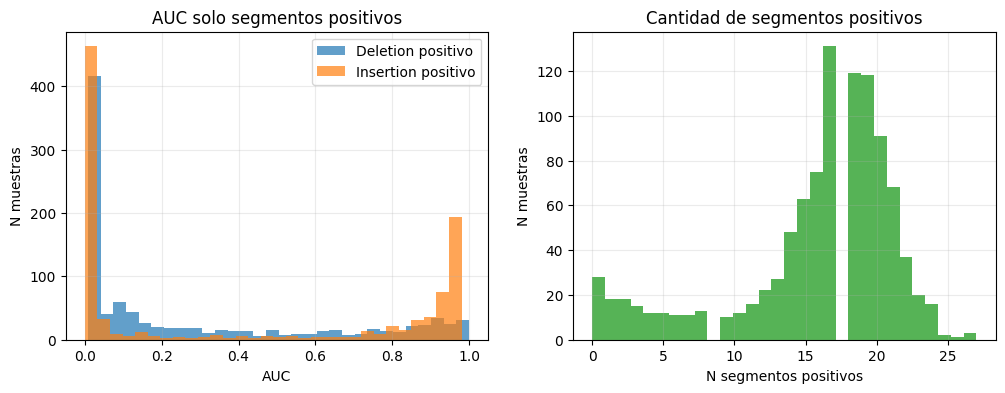

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ok['deletion_auc_positive'].dropna(), bins=30, alpha=.7, label='Deletion positivo')
axes[0].hist(ok['insertion_auc_positive'].dropna(), bins=30, alpha=.7, label='Insertion positivo')
axes[0].set_title('AUC solo segmentos positivos')
axes[0].set_xlabel('AUC')
axes[0].set_ylabel('N muestras')
axes[0].legend()

axes[1].hist(ok['n_positive_segments'], bins=30, alpha=.8, color='tab:green')
axes[1].set_title('Cantidad de segmentos positivos')
axes[1].set_xlabel('N segmentos positivos')
axes[1].set_ylabel('N muestras')

for ax in axes:
    ax.grid(alpha=.25)
plt.show()

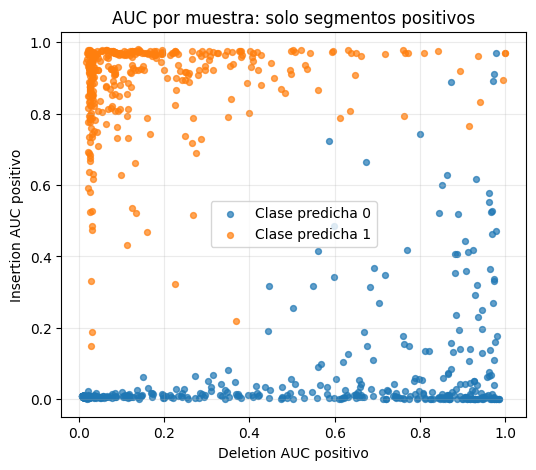

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for class_id, group in ok.groupby('predicted_class'):
    ax.scatter(group['deletion_auc_positive'], group['insertion_auc_positive'], s=18, alpha=.7, label=f'Clase predicha {class_id}')
ax.set(
    xlabel='Deletion AUC positivo',
    ylabel='Insertion AUC positivo',
    title='AUC por muestra: solo segmentos positivos',
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 5. Casos extremos

In [10]:
cols = [
    'sample_idx', 'predicted_class', 'original_prediction', 'r2_mean',
    'deletion_auc_positive', 'insertion_auc_positive', 'gap_auc_positive',
    'n_positive_segments',
]

print('Mejores por gap positivo')
display(ok.sort_values('gap_auc_positive', ascending=False)[cols].head(10))

print('Peores por gap positivo')
display(ok.sort_values('gap_auc_positive', ascending=True)[cols].head(10))

print('Sin segmentos positivos')
display(ok[ok['n_positive_segments'] == 0][cols].head(10))

Mejores por gap positivo


,sample_idx,predicted_class,original_prediction,r2_mean,deletion_auc_positive,insertion_auc_positive,gap_auc_positive,n_positive_segments
853,853,1,1.000000,-0.230878,0.022070,0.978444,0.956374,23
218,218,1,1.000000,-0.859245,0.022746,0.977464,0.954718,22
436,436,1,0.999992,-1.212941,0.023809,0.976391,0.952582,21
602,602,1,1.000000,-0.101356,0.023810,0.976367,0.952558,21
795,795,1,0.567975,-0.822025,0.023820,0.976316,0.952496,21
598,598,1,1.000000,-0.297674,0.023834,0.976173,0.952340,21
459,459,1,0.896256,-0.822182,0.025726,0.976925,0.951199,23
734,734,1,0.999964,-0.385280,0.023809,0.974963,0.951155,21
500,500,1,1.000000,-0.719376,0.025000,0.975210,0.950210,20
1002,1002,1,0.835126,-32.256699,0.019885,0.970075,0.950190,21


Peores por gap positivo


,sample_idx,predicted_class,original_prediction,r2_mean,deletion_auc_positive,insertion_auc_positive,gap_auc_positive,n_positive_segments
732,732,0,0.400416,-0.341203,0.985713,0.000232,-0.985481,21
320,320,0,0.413618,-0.110996,0.983578,0.000234,-0.983344,18
287,287,0,0.396537,-1.315945,0.984566,0.001488,-0.983078,20
51,51,0,0.232930,-0.586272,0.978692,0.000443,-0.978250,18
616,616,0,0.309935,-0.424619,0.978266,0.000248,-0.978018,17
805,805,0,0.042798,-0.844474,0.973403,0.001441,-0.971962,18
1012,1012,0,0.092319,-0.428811,0.973090,0.001233,-0.971858,17
894,894,0,0.012916,-0.340627,0.972383,0.003116,-0.969267,18
506,506,0,0.027822,-0.370641,0.968511,0.000270,-0.968242,16
658,658,0,0.020486,-0.222425,0.972586,0.004345,-0.968241,18


Sin segmentos positivos


,sample_idx,predicted_class,original_prediction,r2_mean,deletion_auc_positive,insertion_auc_positive,gap_auc_positive,n_positive_segments
0,0,0,0.008333,-0.018523,NaN,NaN,NaN,0
35,35,0,0.008129,-0.074702,NaN,NaN,NaN,0
117,117,0,0.008224,-0.024648,NaN,NaN,NaN,0
120,120,0,0.008371,-0.107477,NaN,NaN,NaN,0
126,126,0,0.008156,-0.059739,NaN,NaN,NaN,0
138,138,0,0.007983,-0.030589,NaN,NaN,NaN,0
154,154,0,0.007933,-0.050047,NaN,NaN,NaN,0
170,170,0,0.008359,-0.044162,NaN,NaN,NaN,0
237,237,0,0.007894,-0.041277,NaN,NaN,NaN,0
299,299,0,0.008170,-0.109054,NaN,NaN,NaN,0


### Nota rapida

`NaN` en AUC significa que esa muestra no tuvo segmentos positivos bajo este criterio. Eso no es un error de ejecucion; es informacion del ranking.